In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Rename columns to reframe employees as clients
df.rename(columns={
    'Attrition': 'Churn',
    'JobRole': 'Client_Segment',
    'JobSatisfaction': 'Engagement_Score',
    'YearsAtCompany': 'Years_As_Client',
    'MonthlyIncome': 'Contract_Value',
    'OverTime': 'High_Usage_Flag',
}, inplace=True)

# Convert target to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop irrelevant personal columns
df.drop(columns=['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18'], inplace=True)

df.head()

,Age,Churn,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,Years_As_Client,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


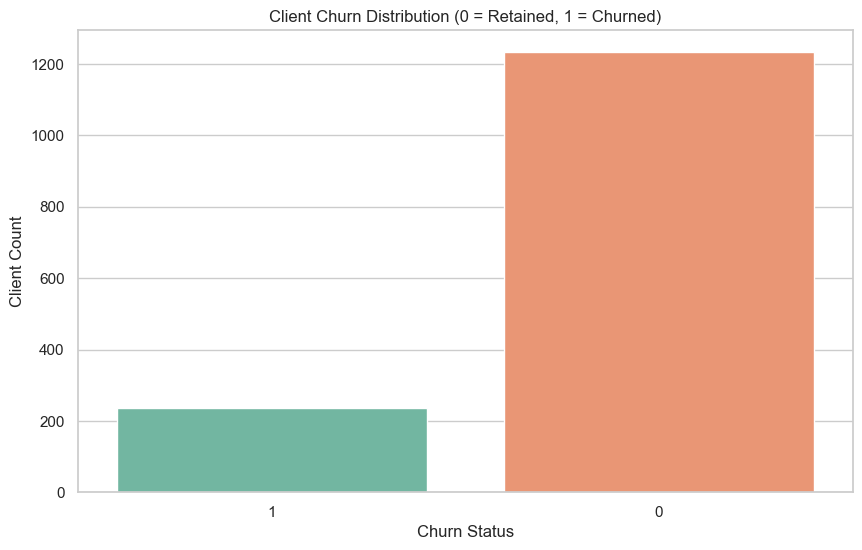

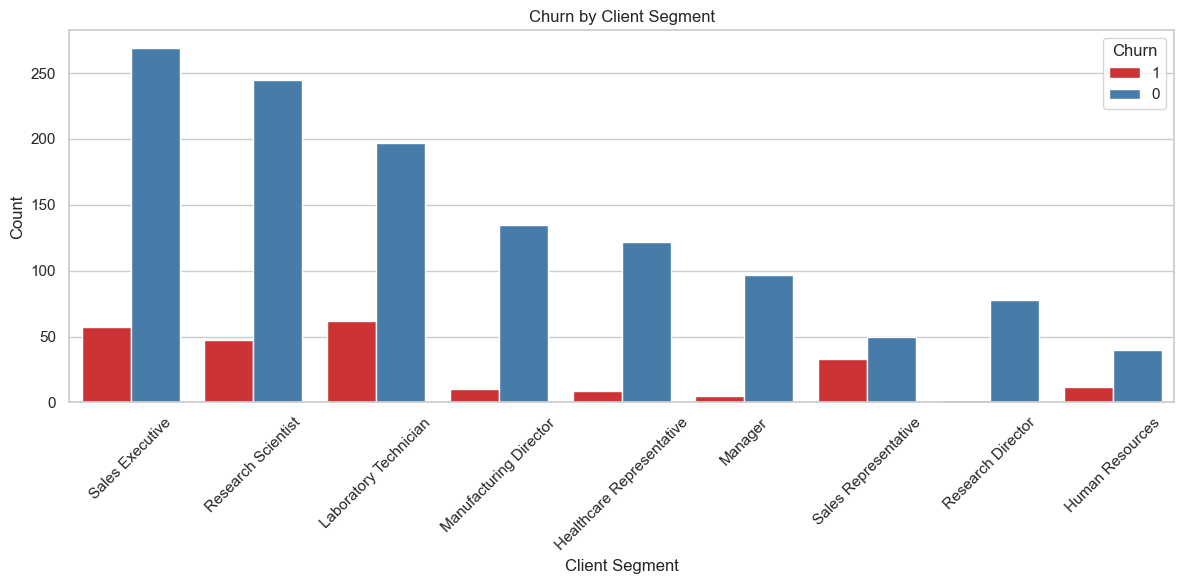

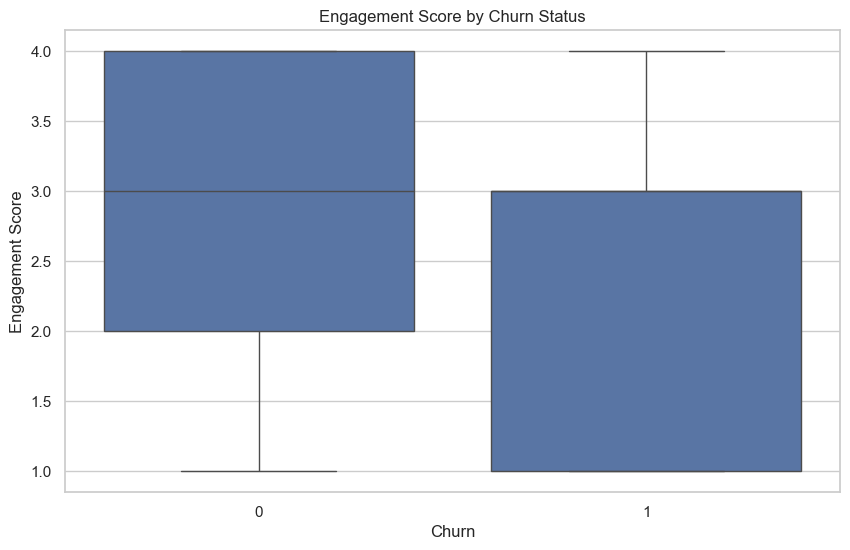

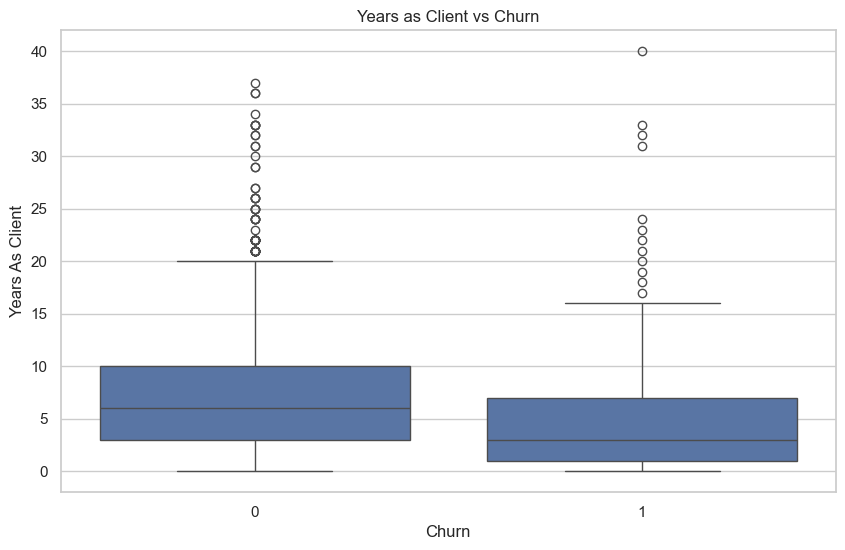

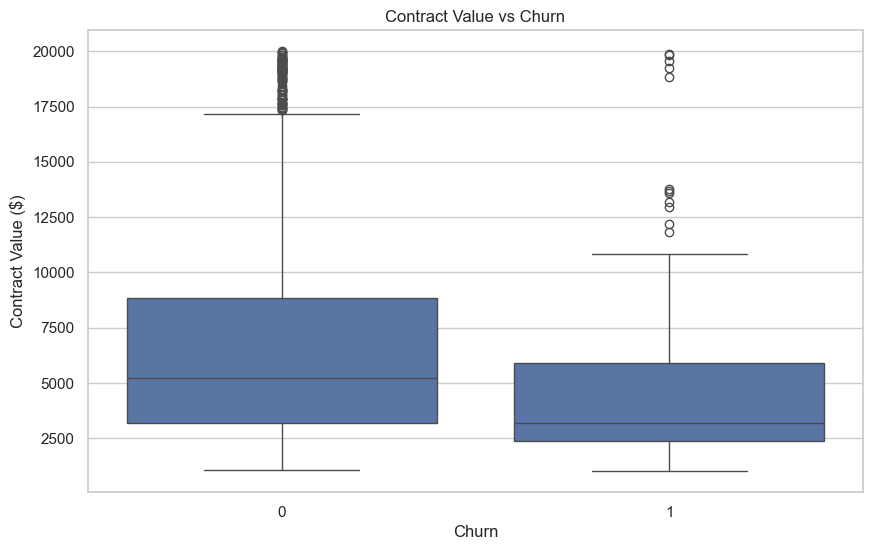

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set theme
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# --- Churn Distribution ---
sns.countplot(data=df.assign(Churn=df['Churn'].astype(str)), x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Client Churn Distribution (0 = Retained, 1 = Churned)')
plt.xlabel('Churn Status')
plt.ylabel('Client Count')
plt.show()

# --- Churn by Client Segment ---
plt.figure(figsize=(12,6))
sns.countplot(data=df.assign(Churn=df['Churn'].astype(str)), x='Client_Segment', hue='Churn', palette='Set1')
plt.title('Churn by Client Segment')
plt.xlabel('Client Segment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

# --- Engagement Score Distribution ---
sns.boxplot(x='Churn', y='Engagement_Score', data=df)
plt.title('Engagement Score by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Engagement Score')
plt.show()

# --- Years as Client vs Churn ---
sns.boxplot(x='Churn', y='Years_As_Client', data=df)
plt.title('Years as Client vs Churn')
plt.xlabel('Churn')
plt.ylabel('Years As Client')
plt.show()

# --- Contract Value vs Churn ---
sns.boxplot(x='Churn', y='Contract_Value', data=df)
plt.title('Contract Value vs Churn')
plt.xlabel('Churn')
plt.ylabel('Contract Value ($)')
plt.show()


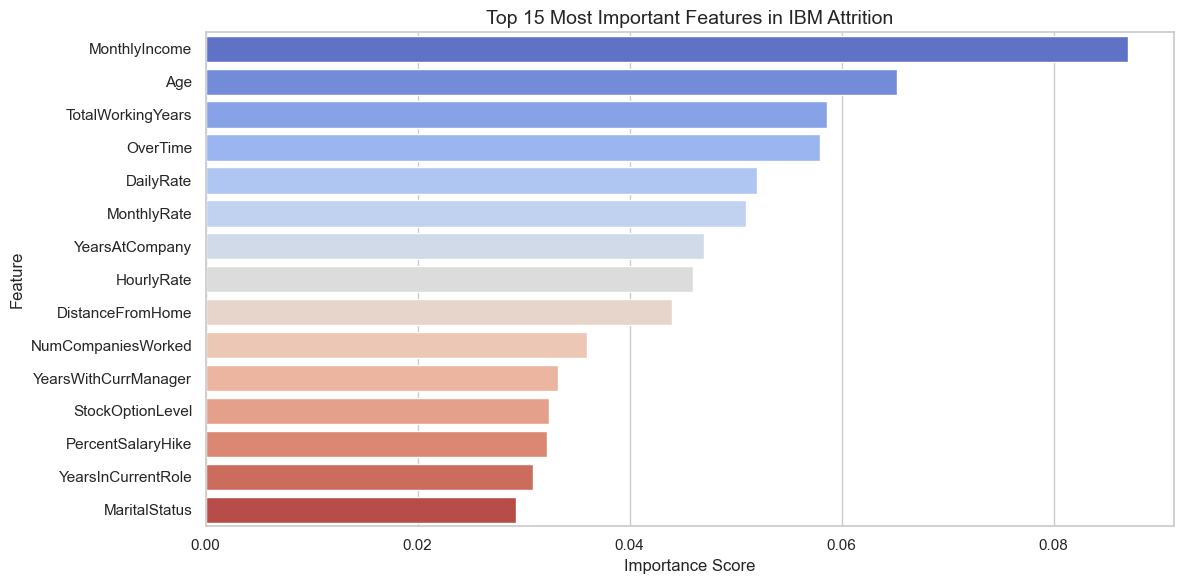

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Load your dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Encode target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Drop columns that are IDs or too unique
df.drop(['EmployeeNumber', 'Over18', 'EmployeeCount', 'StandardHours'], axis=1, inplace=True)

# Label encode categorical columns
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].apply(LabelEncoder().fit_transform)

# Define features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train RandomForest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Feature importances
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Plot Top 15 Features
plt.figure(figsize=(12, 6))
sns.barplot(
    x=importances[indices][:15],
    y=feature_names[indices][:15],
    hue=feature_names[indices][:15],
    palette='coolwarm',
    legend=False
)
plt.title("Top 15 Most Important Features in IBM Attrition", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [8]:
# Create a strategic summary table
top_features = feature_names[indices][:15]
top_importances = importances[indices][:15]

strategic_df = pd.DataFrame({
    'Feature': top_features,
    'Importance Score': top_importances
})

# Add interpretation for top features manually
strategic_df['Strategic Insight'] = [
    "Higher salaries may help retain employees",
    "Younger employees are more likely to churn",
    "More total experience reduces churn risk",
    "Overtime is strongly associated with churn",
    "Daily pay differences reflect inconsistent compensation",
    "MonthlyRate's volatility may affect satisfaction",
    "Longer tenure usually means higher loyalty",
    "Hourly rate may be perceived as undervalued",
    "Greater distance from home increases churn",
    "Frequent job hopping indicates instability",
    "Longer manager relationships reduce churn",
    "Stock incentives help retain staff",
    "Salary hikes promote satisfaction",
    "Stable roles reduce burnout",
    "Married employees show more retention"
]

# Display the strategic summary
import pandas as pd
import IPython.display as disp

disp.display(strategic_df.style.background_gradient(cmap="Blues").set_caption("Top Features Impacting IBM Attrition with Strategic Insights"))


,Feature,Importance Score,Strategic Insight
0,MonthlyIncome,0.087009,Higher salaries may help retain employees
1,Age,0.065254,Younger employees are more likely to churn
2,TotalWorkingYears,0.058657,More total experience reduces churn risk
3,OverTime,0.057966,Overtime is strongly associated with churn
4,DailyRate,0.052011,Daily pay differences reflect inconsistent compensation
5,MonthlyRate,0.051004,MonthlyRate's volatility may affect satisfaction
6,YearsAtCompany,0.047023,Longer tenure usually means higher loyalty
7,HourlyRate,0.045949,Hourly rate may be perceived as undervalued
8,DistanceFromHome,0.044001,Greater distance from home increases churn
9,NumCompaniesWorked,0.035967,Frequent job hopping indicates instability
